### SQL

In [1]:
import sys
!{sys.executable} -m pip install duckdb
!{sys.executable} -m pip install --upgrade pip
import duckdb as db

In [2]:
db.query(
"""
DROP TABLE IF EXISTS sister_clubs CASCADE;
DROP TABLE IF EXISTS clubs CASCADE;

CREATE OR REPLACE TABLE clubs
(
    id INTEGER PRIMARY KEY,
    name STRING NOT NULL UNIQUE,
    dance_genre STRING,
    culture STRING, 
    competitive BOOLEAN,
    hours_per_week INTEGER,
    contract BOOLEAN,
    dues INTEGER,
    travels BOOLEAN,
    skill_level STRING,
    big_littles BOOLEAN,
    covers BOOLEAN,
);

CREATE OR REPLACE TABLE sister_clubs
(
    id INTEGER PRIMARY KEY,
    club1_id INTEGER REFERENCES clubs(id),
    club2_id INTEGER REFERENCES clubs(id),
);
""")

In [3]:
db.query(
"""
INSERT INTO clubs
    (id, name, dance_genre, culture, competitive, hours_per_week, contract, dues, travels, skill_level, big_littles, covers)
VALUES
    (1, 'Ballroom Dancing', 'Ballroom', 'International', TRUE, 6, TRUE, 75, TRUE, 'All levels', TRUE, FALSE),
    (2, 'Salsa Dancing', 'Salsa', 'Latin', FALSE, 4, FALSE, 45, FALSE, 'Beginner-friendly', FALSE, FALSE),
    (3, 'United Movement', 'Hip hop', 'Urban', TRUE, 8, TRUE, 60, TRUE, 'Intermediate', TRUE, TRUE),
    (4, 'Lion Dancing', 'Lion dance', 'Chinese', TRUE, 7, TRUE, 50, TRUE, 'All levels', TRUE, FALSE);

INSERT INTO sister_clubs
    (id, club1_id, club2_id)
VALUES
    (1, 3, 4);
""")

In [4]:
print(db.query("SELECT * FROM clubs"))
print(db.query("SELECT * FROM sister_clubs"))

┌───────┬──────────────────┬─────────────┬───────────────┬─────────────┬────────────────┬──────────┬───────┬─────────┬───────────────────┬─────────────┬─────────┐
│  id   │       name       │ dance_genre │    culture    │ competitive │ hours_per_week │ contract │ dues  │ travels │    skill_level    │ big_littles │ covers  │
│ int32 │     varchar      │   varchar   │    varchar    │   boolean   │     int32      │ boolean  │ int32 │ boolean │      varchar      │   boolean   │ boolean │
├───────┼──────────────────┼─────────────┼───────────────┼─────────────┼────────────────┼──────────┼───────┼─────────┼───────────────────┼─────────────┼─────────┤
│     1 │ Ballroom Dancing │ Ballroom    │ International │ true        │              6 │ true     │    75 │ true    │ All levels        │ true        │ false   │
│     2 │ Salsa Dancing    │ Salsa       │ Latin         │ false       │              4 │ false    │    45 │ false   │ Beginner-friendly │ false       │ false   │
│     3 │ United Movem

### RDF & OWL

In [5]:
import sys
!{sys.executable} -m pip install rdflib
from rdflib import Graph, URIRef, Literal, Namespace, RDF, RDFS, OWL, XSD

In [6]:
EX = Namespace("https://example.edu/dance-clubs/")

dance_graph = Graph()
dance_graph.bind("ex", EX)
dance_graph.bind("owl", OWL)
dance_graph.bind("rdfs", RDFS)

dance_graph.add((EX.Club, RDF.type, OWL.Class))
dance_graph.add((EX.SisterClubRelationship, RDF.type, OWL.Class))
dance_graph.add((EX.sisterClub, RDF.type, OWL.ObjectProperty))
dance_graph.add((EX.sisterClub, RDF.type, OWL.SymmetricProperty))
dance_graph.add((EX.sisterClub, RDFS.domain, EX.Club))
dance_graph.add((EX.sisterClub, RDFS.range, EX.Club))
dance_graph.add((EX.club1, RDF.type, OWL.ObjectProperty))
dance_graph.add((EX.club2, RDF.type, OWL.ObjectProperty))

datatype_properties = {
    EX.sqlId: XSD.integer,
    EX.name: XSD.string,
    EX.danceGenre: XSD.string,
    EX.culture: XSD.string,
    EX.competitive: XSD.boolean,
    EX.hoursPerWeek: XSD.integer,
    EX.contract: XSD.boolean,
    EX.dues: XSD.integer,
    EX.travels: XSD.boolean,
    EX.skillLevel: XSD.string,
    EX.bigLittles: XSD.boolean,
    EX.covers: XSD.boolean,
}

for prop, datatype in datatype_properties.items():
    dance_graph.add((prop, RDF.type, OWL.DatatypeProperty))
    dance_graph.add((prop, RDFS.range, datatype))

clubs = [
    (1, "Ballroom Dancing", "Ballroom", "International", True, 6, True, 75, True, "All levels", True, False),
    (2, "Salsa Dancing", "Salsa", "Latin", False, 4, False, 45, False, "Beginner-friendly", False, False),
    (3, "United Movement", "Hip hop", "Urban", True, 8, True, 60, True, "Intermediate", True, True),
    (4, "Lion Dancing", "Lion dance", "Chinese", True, 7, True, 50, True, "All levels", True, False),
]

club_properties = [
    (EX.sqlId, XSD.integer),
    (EX.name, XSD.string),
    (EX.danceGenre, XSD.string),
    (EX.culture, XSD.string),
    (EX.competitive, XSD.boolean),
    (EX.hoursPerWeek, XSD.integer),
    (EX.contract, XSD.boolean),
    (EX.dues, XSD.integer),
    (EX.travels, XSD.boolean),
    (EX.skillLevel, XSD.string),
    (EX.bigLittles, XSD.boolean),
    (EX.covers, XSD.boolean),
]

club_uris = {}
for club in clubs:
    club_id = club[0]
    club_uri = EX[f"clubs/{club_id}"]
    club_uris[club_id] = club_uri
    dance_graph.add((club_uri, RDF.type, EX.Club))
    dance_graph.add((club_uri, RDFS.label, Literal(club[1])))

    for value, (prop, datatype) in zip(club, club_properties):
        dance_graph.add((club_uri, prop, Literal(value, datatype=datatype)))

sister_clubs = [
    (1, 3, 4),
]

for sister_id, club1_id, club2_id in sister_clubs:
    relationship_uri = EX[f"sister-clubs/{sister_id}"]
    club1_uri = club_uris[club1_id]
    club2_uri = club_uris[club2_id]

    dance_graph.add((relationship_uri, RDF.type, EX.SisterClubRelationship))
    dance_graph.add((relationship_uri, EX.sqlId, Literal(sister_id, datatype=XSD.integer)))
    dance_graph.add((relationship_uri, EX.club1, club1_uri))
    dance_graph.add((relationship_uri, EX.club2, club2_uri))
    dance_graph.add((club1_uri, EX.sisterClub, club2_uri))
    dance_graph.add((club2_uri, EX.sisterClub, club1_uri))

print(dance_graph.serialize(format="turtle"))

@prefix ex: <https://example.edu/dance-clubs/> .
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

ex:bigLittles a owl:DatatypeProperty ;
    rdfs:range xsd:boolean .

ex:club1 a owl:ObjectProperty .

ex:club2 a owl:ObjectProperty .

<https://example.edu/dance-clubs/clubs/1> a ex:Club ;
    rdfs:label "Ballroom Dancing" ;
    ex:bigLittles true ;
    ex:competitive true ;
    ex:contract true ;
    ex:covers false ;
    ex:culture "International"^^xsd:string ;
    ex:danceGenre "Ballroom"^^xsd:string ;
    ex:dues 75 ;
    ex:hoursPerWeek 6 ;
    ex:name "Ballroom Dancing"^^xsd:string ;
    ex:skillLevel "All levels"^^xsd:string ;
    ex:sqlId 1 ;
    ex:travels true .

<https://example.edu/dance-clubs/clubs/2> a ex:Club ;
    rdfs:label "Salsa Dancing" ;
    ex:bigLittles false ;
    ex:competitive false ;
    ex:contract false ;
    ex:covers false ;
    ex:culture "Latin"^^xsd:s

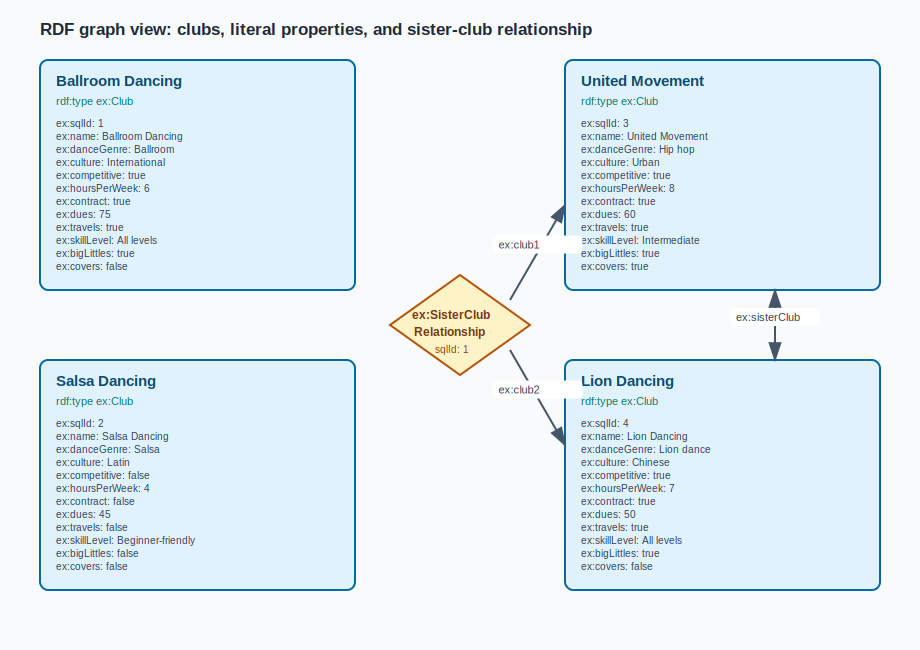

In [7]:
from html import escape
from IPython.display import SVG, display

club_nodes = sorted(
    dance_graph.subjects(RDF.type, EX.Club),
    key=lambda club_uri: int(dance_graph.value(club_uri, EX.sqlId)),
)

club_positions = {
    1: (40, 60),
    2: (40, 360),
    3: (565, 60),
    4: (565, 360),
}
card_width = 315
card_height = 230

display_properties = [
    ("ex:sqlId", EX.sqlId),
    ("ex:name", EX.name),
    ("ex:danceGenre", EX.danceGenre),
    ("ex:culture", EX.culture),
    ("ex:competitive", EX.competitive),
    ("ex:hoursPerWeek", EX.hoursPerWeek),
    ("ex:contract", EX.contract),
    ("ex:dues", EX.dues),
    ("ex:travels", EX.travels),
    ("ex:skillLevel", EX.skillLevel),
    ("ex:bigLittles", EX.bigLittles),
    ("ex:covers", EX.covers),
]

def svg_text(x, y, text, size=12, weight="400", fill="#1f2937"):
    return (
        f'<text x="{x}" y="{y}" font-family="Arial, sans-serif" '
        f'font-size="{size}" font-weight="{weight}" fill="{fill}">{escape(str(text))}</text>'
    )

def labeled_edge(x1, y1, x2, y2, label, marker_end="url(#arrow)", marker_start=""):
    marker_start_attr = f' marker-start="{marker_start}"' if marker_start else ""
    marker_end_attr = f' marker-end="{marker_end}"' if marker_end else ""
    mid_x = (x1 + x2) / 2
    mid_y = (y1 + y2) / 2
    return [
        (
            f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" '
            f'stroke="#475569" stroke-width="2"{marker_start_attr}{marker_end_attr} />'
        ),
        f'<rect x="{mid_x - 45}" y="{mid_y - 17}" width="90" height="18" rx="4" fill="#ffffff" />',
        svg_text(mid_x - 39, mid_y - 4, label, size=11, fill="#334155"),
    ]

svg_parts = [
    '<svg xmlns="http://www.w3.org/2000/svg" width="920" height="650" viewBox="0 0 920 650">',
    '<defs>',
    '<marker id="arrow" markerWidth="10" markerHeight="10" refX="8" refY="3" orient="auto" markerUnits="strokeWidth">',
    '<path d="M0,0 L0,6 L9,3 z" fill="#475569" />',
    '</marker>',
    '<marker id="arrow-start" markerWidth="10" markerHeight="10" refX="1" refY="3" orient="auto" markerUnits="strokeWidth">',
    '<path d="M9,0 L9,6 L0,3 z" fill="#475569" />',
    '</marker>',
    '</defs>',
    '<rect width="920" height="650" fill="#f8fafc" />',
    svg_text(40, 35, "RDF graph view: clubs, literal properties, and sister-club relationship", size=17, weight="700"),
]

for club_uri in club_nodes:
    club_id = int(dance_graph.value(club_uri, EX.sqlId))
    x, y = club_positions[club_id]
    label = dance_graph.value(club_uri, RDFS.label)

    svg_parts.append(f'<rect x="{x}" y="{y}" width="{card_width}" height="{card_height}" rx="8" fill="#e0f2fe" stroke="#0369a1" stroke-width="2" />')
    svg_parts.append(svg_text(x + 16, y + 26, label, size=15, weight="700", fill="#0c4a6e"))
    svg_parts.append(svg_text(x + 16, y + 45, "rdf:type ex:Club", size=11, fill="#0f766e"))

    for row_index, (property_label, prop) in enumerate(display_properties):
        value = dance_graph.value(club_uri, prop)
        svg_parts.append(svg_text(x + 16, y + 67 + (row_index * 13), f"{property_label}: {value}", size=10, fill="#334155"))

relationship_x = 460
relationship_y = 325
svg_parts.append(f'<polygon points="{relationship_x},275 {relationship_x + 70},325 {relationship_x},375 {relationship_x - 70},325" fill="#fef3c7" stroke="#b45309" stroke-width="2" />')
svg_parts.append(svg_text(relationship_x - 48, relationship_y - 6, "ex:SisterClub", size=12, weight="700", fill="#78350f"))
svg_parts.append(svg_text(relationship_x - 46, relationship_y + 11, "Relationship", size=12, weight="700", fill="#78350f"))
svg_parts.append(svg_text(relationship_x - 25, relationship_y + 28, "sqlId: 1", size=10, fill="#92400e"))

club3_x, club3_y = club_positions[3]
club4_x, club4_y = club_positions[4]
svg_parts.extend(labeled_edge(relationship_x + 50, relationship_y - 25, club3_x, club3_y + 145, "ex:club1"))
svg_parts.extend(labeled_edge(relationship_x + 50, relationship_y + 25, club4_x, club4_y + 85, "ex:club2"))
svg_parts.extend(labeled_edge(club3_x + 210, club3_y + card_height, club4_x + 210, club4_y, "ex:sisterClub", marker_start="url(#arrow-start)", marker_end="url(#arrow)"))

svg_parts.append('</svg>')

display(SVG("".join(svg_parts)))